In [1]:
import torch
import zipfile
import os

path = '../inference_dump/inference_dump2.pt'

dump_dict = torch.load(path, weights_only=False)
T_actual = dump_dict['T_actual']
true_objective = dump_dict['true_objective']
true_remaining = dump_dict['true_remaining']
predictions = dump_dict['predictions']
s_weights_cpu = dump_dict['s_weights_cpu']
v_weights_cpu = dump_dict['v_weights_cpu']
data_tensor = dump_dict['data_tensor']

# print shapes of lists and elements
print("T_actual:", T_actual)
print("true_objective length:", len(true_objective))
print("true_objective:", true_objective)
print("true_remaining length:", len(true_remaining))
print("true_remaining:", true_remaining)
print("predictions length:", len(predictions))
print("predictions:", predictions)
print("s_weights_cpu length:", len(s_weights_cpu))
print("s_weights_cpu:", s_weights_cpu[0:5])
print("v_weights_cpu length:", len(v_weights_cpu))
print("v_weights_cpu:", v_weights_cpu[0:5])
print("data_tensor length:", len(data_tensor))
print("data_tensor:", data_tensor[0:5])



T_actual: 68
true_objective length: 68
true_objective: [50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50.0, 49.0, 48.0, 47.0, 46.0, 45.0, 44.0, 43.0, 42.0, 41.0, 40.0, 39.0, 38.0, 37.0, 36.0, 35.0, 34.0, 33.0, 32.0, 31.0, 30.0, 29.0, 28.0, 27.0, 26.0, 25.0, 24.0, 23.0, 22.0, 21.0, 20.0, 19.0, 18.0, 17.0, 16.0, 15.0, 14.0, 13.0, 12.0, 11.0, 10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.0]
true_remaining length: 68
true_remaining: [67.0, 66.0, 65.0, 64.0, 63.0, 62.0, 61.0, 60.0, 59.0, 58.0, 57.0, 56.0, 55.0, 54.0, 53.0, 52.0, 51.0, 50.0, 49.0, 48.0, 47.0, 46.0, 45.0, 44.0, 43.0, 42.0, 41.0, 40.0, 39.0, 38.0, 37.0, 36.0, 35.0, 34.0, 33.0, 32.0, 31.0, 30.0, 29.0, 28.0, 27.0, 26.0, 25.0, 24.0, 23.0, 22.0, 21.0, 20.0, 19.0, 18.0, 17.0, 16.0, 15.0, 14.0, 13.0, 12.0, 11.0, 10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0, 0.0]
predictions length: 68
predictions: [50.24008750915527, 51.13314986228943, 51.55946612358093, 49.82960224151611, 50.18259882926941, 50.3102

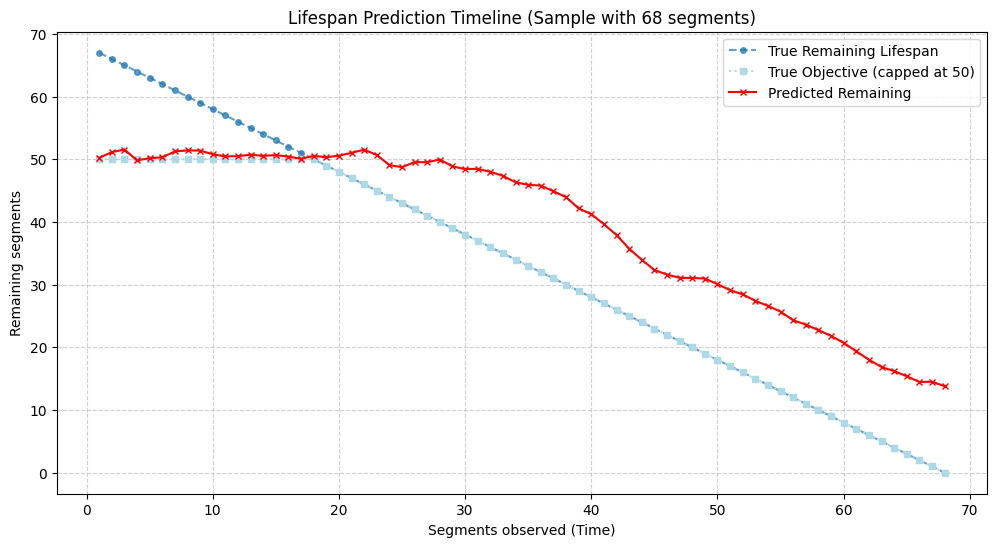

In [39]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(1, T_actual + 1)

plt.figure(figsize=(12, 6))

plt.plot(steps, true_remaining, label="True Remaining Lifespan", linestyle="--", marker="o", markersize=4, alpha=0.7)
plt.plot(steps, true_objective, label="True Objective (capped at 50)", color='lightblue', linestyle=":", marker="s", markersize=4)
plt.plot(steps, predictions, label="Predicted Remaining", color='red', marker="x", markersize=4)

plt.xlabel("Segments observed (Time)")
plt.ylabel("Remaining segments")
plt.title(f"Lifespan Prediction Timeline (Sample with {T_actual} segments)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Top 3 segments by attention: [26 29 25] with weights [0.09151416 0.08665706 0.0755261 ]


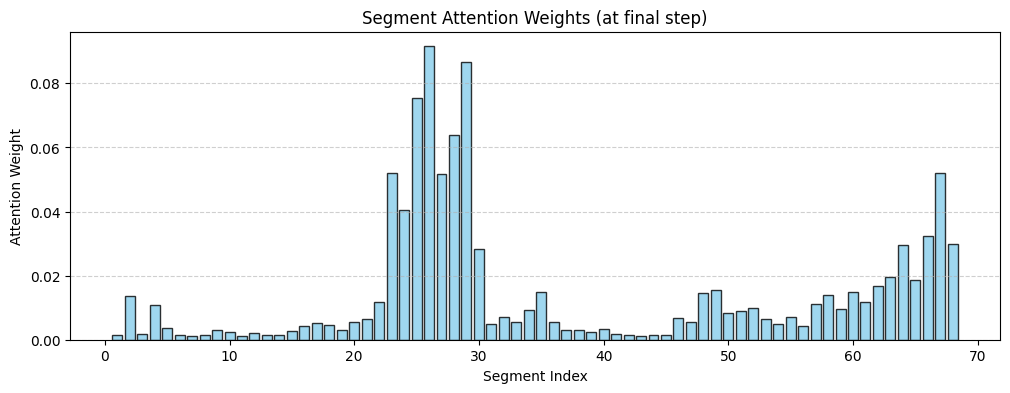

In [40]:
steps = np.arange(1, T_actual + 1)
final_s_weights = np.atleast_1d(s_weights_cpu[-1])

plt.figure(figsize=(12, 4))
plt.bar(steps, final_s_weights, color='skyblue', edgecolor='black', alpha=0.8)

plt.xlabel("Segment Index")
plt.ylabel("Attention Weight")
plt.title("Segment Attention Weights (at final step)")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

top_idx = np.argsort(final_s_weights)[-3:][::-1]
print(f"Top 3 segments by attention: {top_idx + 1} with weights {final_s_weights[top_idx]}")

plt.show()

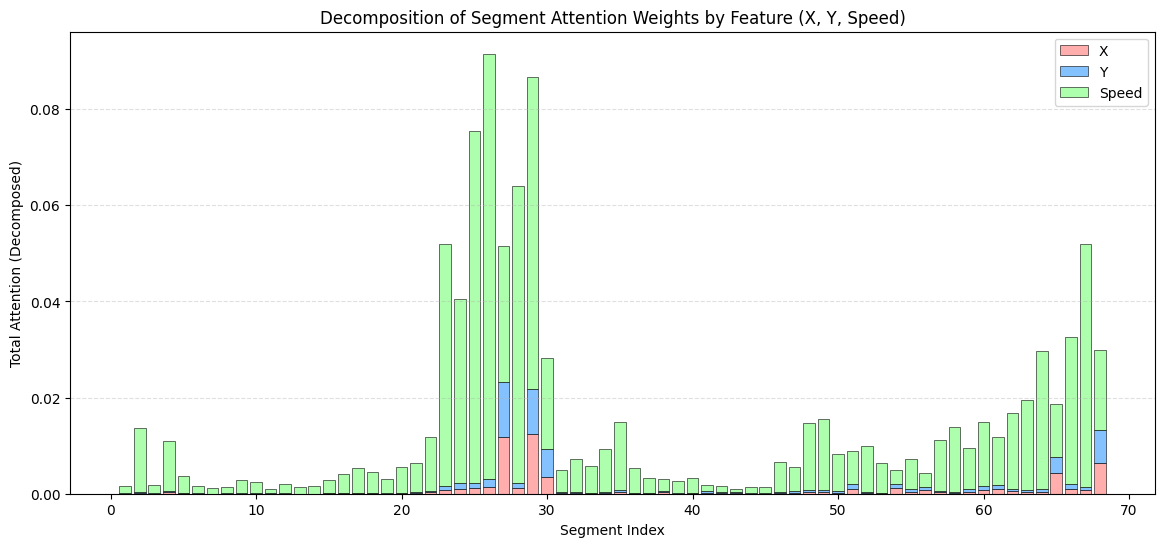

In [41]:
steps = np.arange(1, T_actual + 1)
variates = ["X", "Y", "Speed"]
colors = ["#ff9999", "#66b3ff", "#99ff99"] 
final_s_weights = np.atleast_1d(s_weights_cpu[-1])
final_v_weights = np.atleast_2d(v_weights_cpu[-1])

plt.figure(figsize=(14, 6))

bottom = np.zeros(T_actual)

for i in range(3):
    contribution = final_s_weights * final_v_weights[:, i]
    
    plt.bar(steps, contribution, bottom=bottom, color=colors[i], 
            label=variates[i], edgecolor='black', linewidth=0.5, alpha=0.8)
    bottom += contribution

plt.xlabel("Segment Index")
plt.ylabel("Total Attention (Decomposed)")
plt.title("Decomposition of Segment Attention Weights by Feature (X, Y, Speed)")
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.show()

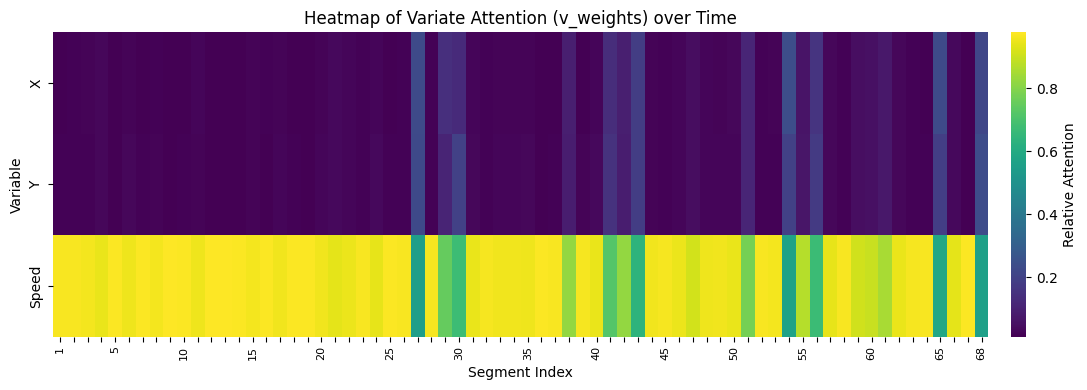

In [42]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 4))
vars_labels = ["X", "Y", "Speed"]
final_v_weights = np.atleast_2d(v_weights_cpu[-1])

sns.heatmap(final_v_weights.T, cmap="viridis", yticklabels=vars_labels, ax=ax, 
            cbar_kws={'label': 'Relative Attention', 'pad': 0.02})

ax.set_xlabel("Segment Index")
ax.set_ylabel("Variable")
ax.set_title("Heatmap of Variate Attention (v_weights) over Time")

ax.set_xticks(np.arange(T_actual) + 0.5)
ax.set_xticklabels(np.arange(1, T_actual + 1), rotation=90, fontsize=8)

if T_actual > 30:
    for i, label in enumerate(ax.xaxis.get_ticklabels()):
        if (i+1) % 5 != 0 and i != 0 and i != T_actual-1:
            label.set_visible(False)

plt.tight_layout()
plt.show()

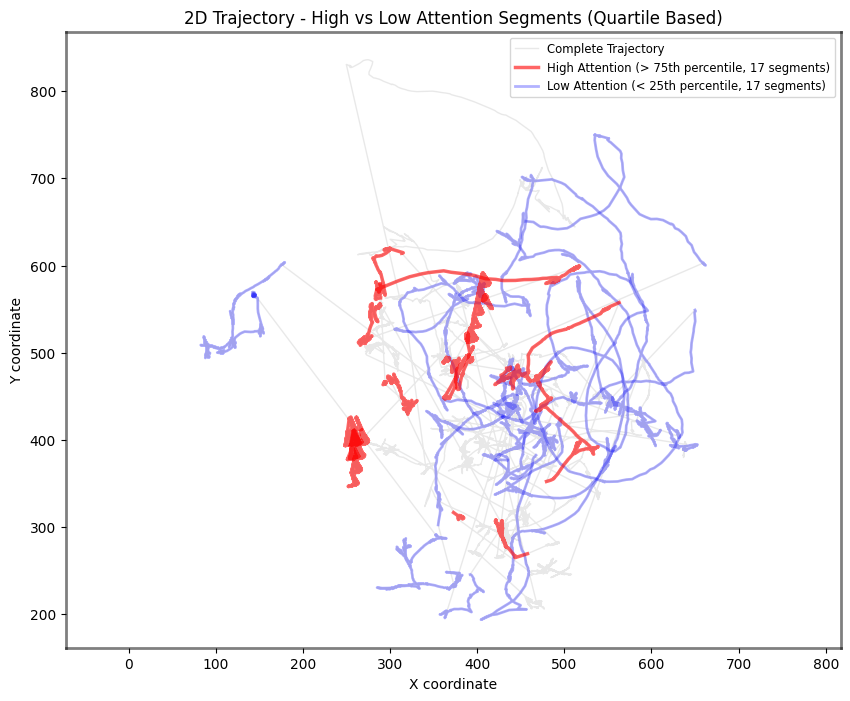

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Based on our checks, the sample with exactly 68 segments is this one:
# 'preprocessed_data2/TERBINAFINE+/coordinates_highestspeed_20250415_9_3_with_time_speed.csv'
file_path = '../preprocessed_data2/TERBINAFINE+/coordinates_highestspeed_20250415_9_3_with_time_speed.csv'

df = pd.read_csv(file_path)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot the full true trajectory from the original dataframe
ax.plot(df['X'], df['Y'], color='lightgray', alpha=0.5, linewidth=1, zorder=1, label="Complete Trajectory")

# Calculate quartiles for attention weights
final_s_weights = np.atleast_1d(s_weights_cpu[-1])
q3_attention = np.percentile(final_s_weights, 75)
q1_attention = np.percentile(final_s_weights, 25)

high_attention_idx = np.where(final_s_weights > q3_attention)[0]
low_attention_idx = np.where(final_s_weights < q1_attention)[0]

# Plot high attention segments (> 3rd quartile)
for i, seg_idx in enumerate(high_attention_idx):
    seg_data = df[df['Segment'] == seg_idx]
    label = f"High Attention (> 75th percentile, {len(high_attention_idx)} segments)" if i == 0 else ""
    ax.plot(seg_data['X'], seg_data['Y'], color='red', linewidth=2.5, alpha=0.6, 
            label=label, zorder=10)

# Plot low attention segments (< 1st quartile)
for i, seg_idx in enumerate(low_attention_idx):
    seg_data = df[df['Segment'] == seg_idx]
    label = f"Low Attention (< 25th percentile, {len(low_attention_idx)} segments)" if i == 0 else ""
    ax.plot(seg_data['X'], seg_data['Y'], color='blue', linewidth=2, alpha=0.3, 
            label=label, zorder=5)

ax.axis('equal')
ax.set_title("2D Trajectory - High vs Low Attention Segments (Quartile Based)")
ax.set_xlabel("X coordinate")
ax.set_ylabel("Y coordinate")
ax.legend(fontsize='small', loc='upper right')

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2)
    spine.set_alpha(0.5)

plt.show()

In [40]:
import plotly.graph_objects as go
import numpy as np

# 1. Build the full attention matrix and the feature-specific weights matrix
S_matrix = np.zeros((T_actual, T_actual))
V_matrix = np.zeros((T_actual, T_actual, 3))

for t in range(T_actual):
    s_W = np.atleast_1d(s_weights_cpu[t])
    v_W = np.atleast_2d(v_weights_cpu[t])
    length = len(s_W)
    
    # Store global segment attention
    S_matrix[t, :length] = s_W
    # Store the 3 variants' attention (X, Y, Speed) per segment
    V_matrix[t, :length, :] = v_W[:length, :]

# 2. Decompose the total attention into its X, Y, and Speed components
Attn_X     = S_matrix * V_matrix[:, :, 0]
Attn_Y     = S_matrix * V_matrix[:, :, 1]
Attn_Speed = S_matrix * V_matrix[:, :, 2]

# Mask unobserved segments with NaN to hide them completely (so 0s aren't displayed)
mask = (S_matrix == 0)
Attn_X[mask] = np.nan
Attn_Y[mask] = np.nan
Attn_Speed[mask] = np.nan

# Stacking them so they build up to the total attention on the Z-axis
Z1 = Attn_X
Z2 = Z1 + Attn_Y
Z3 = Z2 + Attn_Speed

x_seg = np.arange(1, T_actual + 1)
y_time = np.arange(1, T_actual + 1)

# Prepare custom text array for unified hover tooltips
# Using a 2D numpy text matrix and purely 'text' hoverinfo to bypass WebGL template limitations
hover_text_array = np.empty((T_actual, T_actual), dtype=object)
for i in range(T_actual): # y_time is row index
    for j in range(T_actual): # x_seg is col index
        if mask[i, j]:
            hover_text_array[i, j] = ""
        else:
            tot = Z3[i, j]
            x_v = Z1[i, j]
            y_v = Z2[i, j] - Z1[i, j]
            s_v = Z3[i, j] - Z2[i, j]
            hover_text_array[i, j] = (
                f"<b>Time observed:</b> {i+1}<br>"
                f"<b>Segment focus:</b> {j+1}<br>"
                f"<b>Total Attn:</b> {tot:.5f}<br>"
                f"➡ X Attn: {x_v:.5f}<br>"
                f"➡ Y Attn: {y_v:.5f}<br>"
                f"➡ Speed Attn: {s_v:.5f}"
            )

# 3. Create interactive figure
fig = go.Figure()

# To make the composition clearly visible, we'll plot them as solid blocks 
# by making the surfaces fully opaque but brightly colored and using dense constant-X contours.

# Base layer: X Component (Red)
fig.add_trace(go.Surface(
    z=Z1, x=x_seg, y=y_time, 
    name='1. X Attn', colorscale=[[0, 'rgb(255,220,220)'], [1, 'rgb(255,50,50)']], 
    showscale=False, opacity=1.0,
    text=hover_text_array, hoverinfo='text',
    contours=dict(
        x=dict(show=True, start=1, end=T_actual, size=1, color='darkred', width=1.5, highlightcolor='red'),
        y=dict(show=False),
        z=dict(show=False)
    )
))

# Middle layer: X + Y Components (Blue)
fig.add_trace(go.Surface(
    z=Z2, x=x_seg, y=y_time, 
    surfacecolor=Z2 - Z1, # Color only by the Y magnitude so the blue pops based on its own thickness
    name='2. + Y Attn', colorscale=[[0, 'rgb(220,220,255)'], [1, 'rgb(50,50,255)']], 
    showscale=False, opacity=1.0,
    text=hover_text_array, hoverinfo='text',
    contours=dict(
        x=dict(show=True, start=1, end=T_actual, size=1, color='darkblue', width=1.5, highlightcolor='blue'),
        y=dict(show=False),
        z=dict(show=False)
    )
))

# Top layer: Total (X + Y + Speed) (Green)
fig.add_trace(go.Surface(
    z=Z3, x=x_seg, y=y_time, 
    surfacecolor=Z3 - Z2, # Color only by the Speed magnitude so green pops based on its own thickness
    name='3. + Speed (Total)', colorscale=[[0, 'rgb(220,255,220)'], [1, 'rgb(50,255,50)']], 
    showscale=False, opacity=1.0,
    text=hover_text_array, hoverinfo='text',
    contours=dict(
        x=dict(show=True, start=1, end=T_actual, size=1, color='darkgreen', width=1.5, highlightcolor='green'), 
        y=dict(show=False),
        z=dict(show=False)
    )
))

# 4. Predictions on the "back wall"
max_attn = np.nanmax(Z3)
# Max[pred, truncated lifespan] with a small rounding margin to the nearest 10
max_raw_val = max(np.max(predictions), np.max(true_objective))
max_val = np.ceil(max_raw_val / 10) * 10
if max_val == 0:
    max_val = 50.0

# Ensure Max[pred, truncated lifespan] == weight of 1
scaling_factor = 1.0 / max_val

scaled_preds = np.array(predictions) * scaling_factor
scaled_trues = np.array(true_objective) * scaling_factor

x_wall = np.full(T_actual, 1)  # Changed from T_actual to 1 to move to opposite wall

fig.add_trace(go.Scatter3d(
    x=x_wall, y=y_time, z=scaled_preds,
    mode='lines+markers', line=dict(color='magenta', width=8), marker=dict(size=4, color='magenta'),
    name='Predicted Lifespan',
    text=predictions, hovertemplate="<b>Predicted Lifespan:</b> %{text:.1f} years<extra></extra>"
))
fig.add_trace(go.Scatter3d(
    x=x_wall, y=y_time, z=scaled_trues,
    mode='lines', line=dict(color='cyan', width=8, dash='dash'),
    name='True Lifespan (Capped)',
    text=true_objective, hovertemplate="<b>True Lifespan:</b> %{text:.1f} years<extra></extra>"
))

# Set a better default viewing angle (zoom in more)
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=-0.2), # shift center down to look more 'into' the plot
    eye=dict(x=-1.2, y=-1.2, z=0.5) # Zoomed in closer, lower angle
)

# Generate custom tick text labels for the Z-axis so it explicitly shows BOTH original scales
# We pick a set of round reference points for 'Years' (Lifespan) and calculate where they fall.
num_ticks = 6
y_ref_step = max_val / (num_ticks - 1)
tick_vals = []
tick_texts = []

for i in range(num_ticks):
    y_val = i * y_ref_step
    z_phys = y_val * scaling_factor
    tick_vals.append(z_phys)
    
    # We display both the raw physical Z value (Weight) AND the Lifespan (Years) it represents
    # Adding unicode non-breaking spaces at the end to push the labels physically further left from the 3D data wall
    tick_texts.append(f"{z_phys:.1f} W.  |  {int(y_val)} yrs" + "\u00A0" * 8)

# 5. Add interactive dropdown to select variable combinations dynamically.
# Note: traces order -> 0: X, 1: Y, 2: Speed, 3: Predicted Line, 4: True Line
# We explicitly rewrite the Z layers on update so that isolated isolated drop to rest on Z=0
# without superposition floating in mid-air!
z_all = [Attn_X, Attn_X + Attn_Y, Attn_X + Attn_Y + Attn_Speed, scaled_preds, scaled_trues]
z_x   = [Attn_X, Attn_Y, Attn_Speed, scaled_preds, scaled_trues]
z_y   = [Attn_X, Attn_Y, Attn_Speed, scaled_preds, scaled_trues]
z_s   = [Attn_X, Attn_Y, Attn_Speed, scaled_preds, scaled_trues]
z_xy  = [Attn_X, Attn_X + Attn_Y, Attn_Speed, scaled_preds, scaled_trues]
z_xs  = [Attn_X, Attn_Y, Attn_X + Attn_Speed, scaled_preds, scaled_trues]
z_ys  = [Attn_X, Attn_Y, Attn_Y + Attn_Speed, scaled_preds, scaled_trues]

updatemenus = [dict(
    type="dropdown",
    direction="down",
    x=0.01,
    y=1.1,
    xanchor='left',
    yanchor='top',
    buttons=list([
        dict(label="View: All Stacked (X+Y+Speed)", method="update",
             args=[{"visible": [True, True, True, True, True], "z": z_all},
                   {"title": "Composition: All Connected Features Stacked"}]),
        dict(label="View: X Only", method="update",
             args=[{"visible": [True, False, False, True, True], "z": z_x},
                   {"title": "Isolated: X Attention (Resting on 0)"}]),
        dict(label="View: Y Only", method="update",
             args=[{"visible": [False, True, False, True, True], "z": z_y},
                   {"title": "Isolated: Y Attention (Resting on 0)"}]),
        dict(label="View: Speed Only", method="update",
             args=[{"visible": [False, False, True, True, True], "z": z_s},
                   {"title": "Isolated: Speed Attention (Resting on 0)"}]),
        dict(label="View: X + Y Stacked", method="update",
             args=[{"visible": [True, True, False, True, True], "z": z_xy},
                   {"title": "Combination: X + Y Stacked"}]),
        dict(label="View: X + Speed", method="update",
             args=[{"visible": [True, False, True, True, True], "z": z_xs},
                   {"title": "Combination: X + Speed Stacked"}]),
        dict(label="View: Y + Speed", method="update",
             args=[{"visible": [False, True, True, True, True], "z": z_ys},
                   {"title": "Combination: Y + Speed Stacked"}])
    ]),
    pad={"r": 10, "t": 10},
    showactive=True,
    bgcolor="white",
    bordercolor="black"
)]

# 6. Fine-tune layout for optimal view
fig.update_layout(
    title=dict(text='Interactive 3D Attention Composition & Trajectory Predictions', x=0.5, y=0.98),
    updatemenus=updatemenus,
    annotations=[
        dict(
            x=0.01,
            y=0.95,
            text="Z-Axis: Attention Weights | Lifespan",
            xref="paper",
            yref="paper",
            showarrow=False,
            font=dict(size=14, color="black"),
            align="left"
        )
    ],
    scene=dict(
        xaxis_title='Segment Index (Focus)',
        yaxis_title='Inference Time (Observed)',
        zaxis_title='', # Explicitly set to empty to override the default "z"
        xaxis=dict(range=[1, T_actual], backgroundcolor="rgb(230, 230, 230)", gridcolor="white", showbackground=True),
        yaxis=dict(range=[1, T_actual], backgroundcolor="rgb(230, 230, 230)", gridcolor="white", showbackground=True),
        zaxis=dict(
            range=[0, max_attn * 1.6], 
            backgroundcolor="rgb(240, 240, 240)", 
            gridcolor="white", 
            showbackground=True,
            # Force the Z-axis labels to display both Attention Weight and back-calculated Years!
            tickmode='array',
            tickvals=tick_vals,
            ticktext=tick_texts
        ),
        aspectratio=dict(x=1.2, y=1.2, z=0.8), # Stretch the X and Y axes out to give the blocks more physical room
        camera=camera
    ),
    autosize=True, # Allow it to fill the entire notebook cell dynamically
    height=800,
    margin=dict(l=0, r=0, b=0, t=60), # Keep absolute zero margins around the 3D bounds
    paper_bgcolor='white',
    plot_bgcolor='white'
)

fig.show()